# Real-time Emotion Detection System
Detects 7 emotions from a webcam using a CNN trained on FER-2013.

**Emotions:** angry · disgust · fear · happy · neutral · sad · surprise

## Step 1 — Install Libraries
Run this once, then restart the kernel.

In [1]:
!pip install tensorflow opencv-python numpy matplotlib scikit-learn seaborn

Defaulting to user installation because normal site-packages is not writeable


## Step 2 — Import Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow:', tf.__version__)
print('OpenCV:', cv2.__version__)
print('All good ✓')

TensorFlow: 2.21.0
OpenCV: 4.13.0
All good ✓


## Step 3 — Settings

In [3]:
IMG_SIZE   = 48
BATCH_SIZE = 64
EPOCHS     = 50

TRAIN_DIR  = '../data/train'
TEST_DIR   = '../data/test'
MODEL_PATH = '../model/emotion_model.keras'

EMOTIONS = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# Color per emotion for the webcam box (BGR)
COLORS = {
    'angry':    (0,   0,   220),
    'disgust':  (0,   140, 0  ),
    'fear':     (140, 0,   140),
    'happy':    (0,   210, 0  ),
    'neutral':  (180, 180, 180),
    'sad':      (220, 100, 0  ),
    'surprise': (0,   200, 220),
}

os.makedirs('../model', exist_ok=True)
print('Settings ready ✓')

Settings ready ✓


## Step 4 — Load Dataset

> Download FER-2013 from https://www.kaggle.com/datasets/msambare/fer2013  
> Extract it so you have: `data/train/` and `data/test/` folders next to this repo.

In [4]:
# Training data — with augmentation
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
).flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Test data — no augmentation
test_gen = ImageDataGenerator(
    rescale=1./255
).flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print('Dataset loaded ✓')

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Dataset loaded ✓


## Step 5 — Preview Dataset

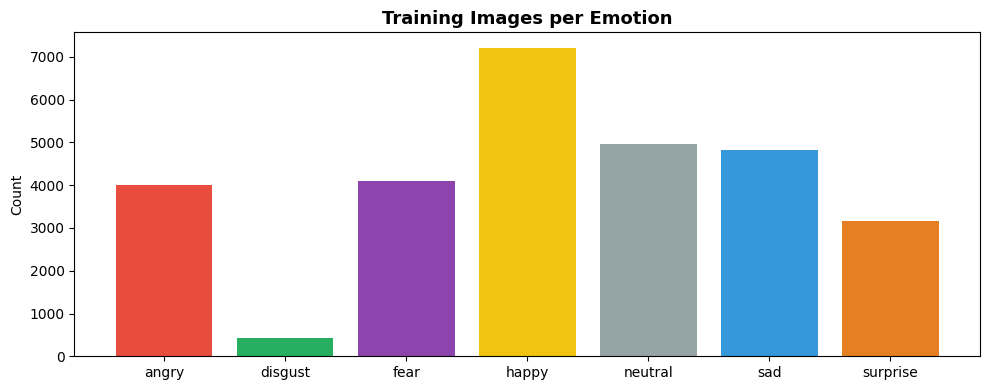

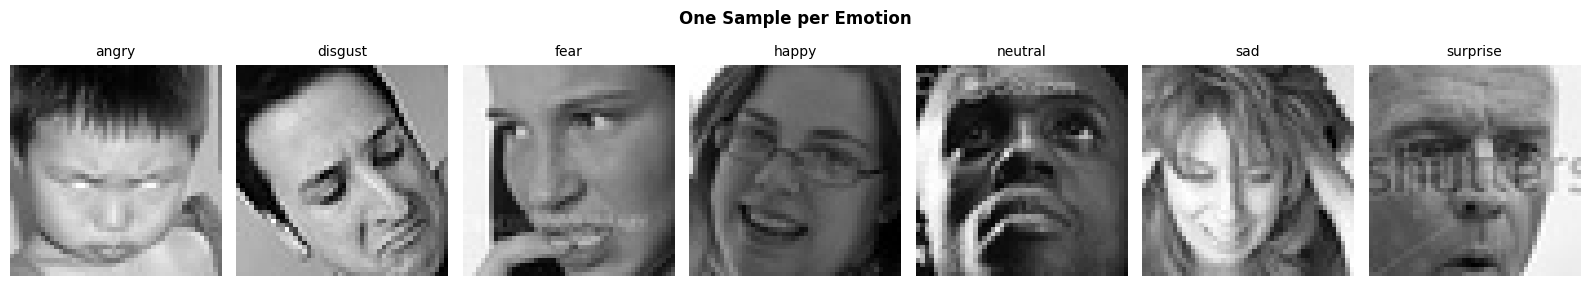

In [5]:
# Class counts bar chart
counts = {e: len(os.listdir(os.path.join(TRAIN_DIR, e))) for e in EMOTIONS}

plt.figure(figsize=(10, 4))
plt.bar(counts.keys(), counts.values(),
        color=['#e74c3c','#27ae60','#8e44ad','#f1c40f','#95a5a6','#3498db','#e67e22'])
plt.title('Training Images per Emotion', fontsize=13, fontweight='bold')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Sample images
fig, axes = plt.subplots(1, 7, figsize=(16, 3))
for ax, emotion in zip(axes, EMOTIONS):
    folder = os.path.join(TRAIN_DIR, emotion)
    img    = cv2.imread(os.path.join(folder, os.listdir(folder)[0]), cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap='gray')
    ax.set_title(emotion, fontsize=10)
    ax.axis('off')
plt.suptitle('One Sample per Emotion', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 6 — Build CNN Model

In [6]:
model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Output
    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(7, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 48, 48, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 48, 48, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 48, 48, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 24, 24, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 24, 24, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 24, 24, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 12, 12, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 12, 12, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       1,179,904 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 1,470,055 (5.61 MB)

 Trainable params: 1,469,095 (5.60 MB)

 Non-trainable params: 960 (3.75 KB)

## Step 7 — Train Model

In [7]:
callbacks = [
    ModelCheckpoint(MODEL_PATH, monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=test_gen,
    callbacks=callbacks
)

print(f'\nBest model saved → {MODEL_PATH}')

Epoch 1/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 804ms/step - accuracy: 0.2251 - loss: 2.1849
Epoch 1: val_accuracy improved from None to 0.28727, saving model to ../model/emotion_model.keras

Epoch 1: finished saving model to ../model/emotion_model.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 403s 875ms/step - accuracy: 0.2594 - loss: 1.9706 - val_accuracy: 0.2873 - val_loss: 1.7512 - learning_rate: 0.0010
Epoch 2/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 838ms/step - accuracy: 0.3608 - loss: 1.6458
Epoch 2: val_accuracy improved from 0.28727 to 0.44177, saving model to ../model/emotion_model.keras

Epoch 2: finished saving model to ../model/emotion_model.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 400s 890ms/step - accuracy: 0.3884 - loss: 1.5761 - val_accuracy: 0.4418 - val_loss: 1.4133 - learning_rate: 0.0010
Epoch 3/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 763ms/step - accuracy: 0.4489 - loss: 1.4369
Epoch 3: val_accuracy improved from 0.44177 to 0.49485, saving model to ../model/emotion_model.keras

Epoch 3: finished

## Step 8 — Plot Training Results

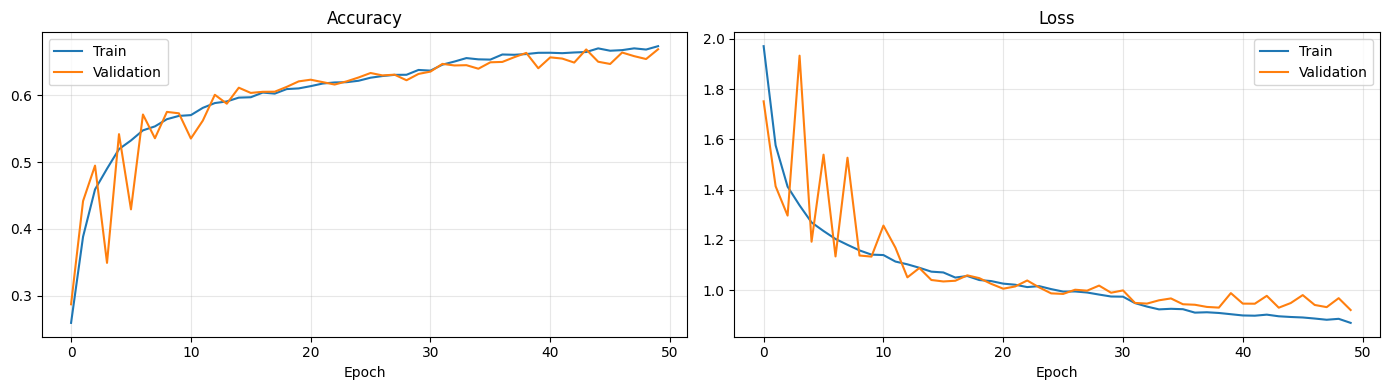

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 9 — Evaluate Model

Test Accuracy : 66.90%
Test Loss     : 0.9210
113/113 ━━━━━━━━━━━━━━━━━━━━ 20s 175ms/step

Classification Report:
              precision    recall  f1-score   support

       angry       0.59      0.59      0.59       958
     disgust       0.74      0.48      0.58       111
        fear       0.60      0.37      0.46      1024
       happy       0.85      0.89      0.87      1774
     neutral       0.55      0.75      0.63      1233
         sad       0.57      0.52      0.54      1247
    surprise       0.76      0.79      0.78       831

    accuracy                           0.67      7178
   macro avg       0.67      0.63      0.64      7178
weighted avg       0.67      0.67      0.66      7178



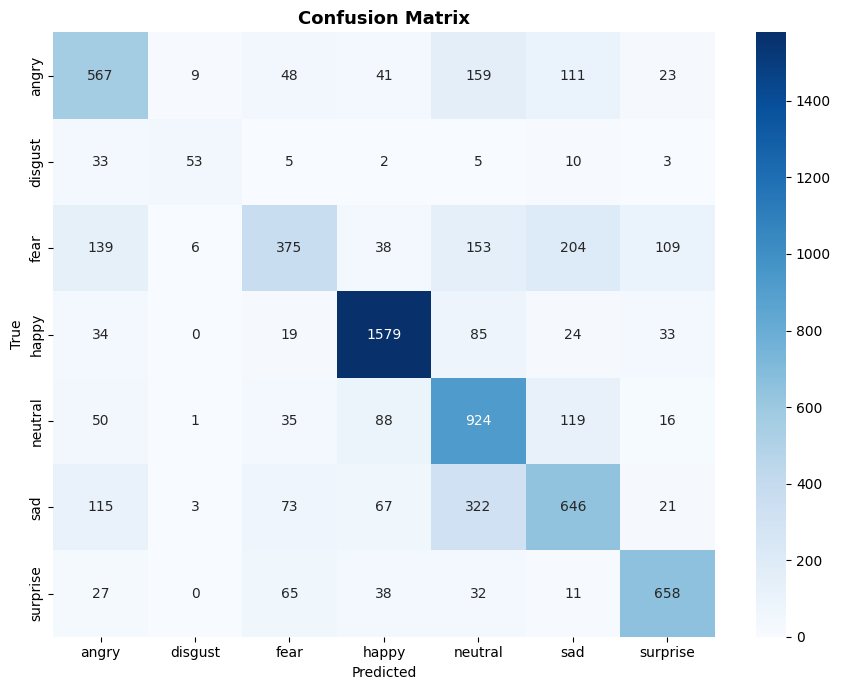

In [9]:
model = tf.keras.models.load_model(MODEL_PATH)

loss, acc = model.evaluate(test_gen, verbose=0)
print(f'Test Accuracy : {acc * 100:.2f}%')
print(f'Test Loss     : {loss:.4f}')

test_gen.reset()
y_pred = np.argmax(model.predict(test_gen), axis=1)
y_true = test_gen.classes

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=EMOTIONS))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=EMOTIONS, yticklabels=EMOTIONS)
plt.title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Step 10 — Real-time Webcam Detection
> Press **Q** to quit.

In [10]:
model        = tf.keras.models.load_model(MODEL_PATH)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    raise RuntimeError('Cannot open webcam.')

print('Webcam running — press Q to quit')

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(48, 48))

    for (x, y, w, h) in faces:
        # Preprocess
        face  = cv2.resize(gray[y:y+h, x:x+w], (48, 48))
        face  = face.astype('float32') / 255.0
        face  = np.expand_dims(face, axis=(0, -1))

        # Predict
        preds      = model.predict(face, verbose=0)[0]
        emotion    = EMOTIONS[np.argmax(preds)]
        confidence = preds.max() * 100
        color      = COLORS[emotion]

        # Draw box
        cv2.rectangle(frame, (x, y), (x+w, y+h), color, 2)

        # Draw label
        label = f'{emotion.upper()}  {confidence:.0f}%'
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.65, 2)
        cv2.rectangle(frame, (x, y-th-12), (x+tw+8, y), color, -1)
        cv2.putText(frame, label, (x+4, y-6), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255,255,255), 2)

    cv2.putText(frame, 'Press Q to quit', (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200,200,200), 1)
    cv2.imshow('Emotion Detection', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
print('Done.')

Webcam running — press Q to quit
Done.
